## Creating and Using Matrices

In [1]:
import geopandas as gp
import numpy as np
import pandas as pd
from shapely.geometry import Point, LineString

### Join

Using `join` to create a frame with all combinations of two lists of objects.

In [2]:
pf = pd.DataFrame({'point': ['P0','P1','P2']})
pf

,point
0,P0
1,P1
2,P2


In [3]:
sf = pd.DataFrame({'segment': ['A-B', 'B-C', 'C-D', 'D-E']})
sf

,segment
0,A-B
1,B-C
2,C-D
3,D-E


In [4]:
pd.DataFrame.join(pf, sf, how="cross")

,point,segment
0,P0,A-B
1,P0,B-C
2,P0,C-D
3,P0,D-E
4,P1,A-B
5,P1,B-C
6,P1,C-D
7,P1,D-E
8,P2,A-B
9,P2,B-C


### Test Data

Create some nuclei at known positions (to easily check distance calculations).  Putting them in a geometry column in a GeoDataFrame allows us to call Shapely methods on the entire column.

In [5]:
pf = gp.GeoDataFrame({'nucleus': [
    Point(3,3),
    Point(8,3),
    Point(9.5,3),
    Point(14,3),
    Point(5,4),
    Point(7,7),
    Point(9.5,7),
    Point(15,7),
]}, geometry='nucleus')
pf

,nucleus
0,POINT (3 3)
1,POINT (8 3)
2,POINT (9.5 3)
3,POINT (14 3)
4,POINT (5 4)
5,POINT (7 7)
6,POINT (9.5 7)
7,POINT (15 7)


In [6]:
pf.dtypes

nucleus    geometry
dtype: object

Define end points of line segments to use in tests.

In [7]:
end_points = {
    'A': Point(3,4),
    'B': Point(6,3),
    'C': Point(9,5),
    'D': Point(12,2),
    'E': Point(15,5),
}

One way to represent segments uses LineString:

In [8]:
gp.GeoDataFrame({'segment': [
    LineString([end_points['A'], end_points['B']]),
    LineString([end_points['B'], end_points['C']]),
    LineString([end_points['C'], end_points['D']]),
    LineString([end_points['D'], end_points['E']]),
]}, geometry='segment')

,segment
0,"LINESTRING (3 4, 6 3)"
1,"LINESTRING (6 3, 9 5)"
2,"LINESTRING (9 5, 12 2)"
3,"LINESTRING (12 2, 15 5)"


An alternative stores points in two separate columns -- this allows us easier access to the points, _e.g._ when computing angles and midpoints.

In [9]:
gp.GeoDataFrame({
    'start': [end_points['A'], end_points['B'], end_points['C'], end_points['D']],
    'end':   [end_points['B'], end_points['C'], end_points['D'], end_points['E']],
}).set_geometry('start').set_geometry('end')

,start,end
0,POINT (3 4),POINT (6 3)
1,POINT (6 3),POINT (9 5)
2,POINT (9 5),POINT (12 2)
3,POINT (12 2),POINT (15 5)


For convenience make a frame that has both representations.  It's redundant, but we need both,
and it's far more efficient to make the line segments here before they are replicated in the full
matrix.

In [10]:
sf = gp.GeoDataFrame({
    'start': [end_points['A'], end_points['B'], end_points['C'], end_points['D']],
    'end':   [end_points['B'], end_points['C'], end_points['D'], end_points['E']],
    'segment': [
        LineString([end_points['A'], end_points['B']]),
        LineString([end_points['B'], end_points['C']]),
        LineString([end_points['C'], end_points['D']]),
        LineString([end_points['D'], end_points['E']]),
    ],
}).set_geometry('start').set_geometry('end').set_geometry('segment')

In [11]:
sf.dtypes

start      geometry
end        geometry
segment    geometry
dtype: object

### Plot

A quick look at the points and segments

<Axes: >

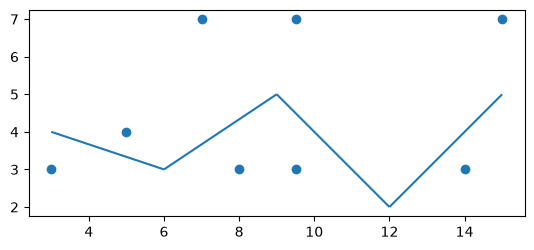

In [12]:
ax = pf.plot()
sf.segment.plot(ax=ax)

### Distance

Examples of distance from point to segment

In [13]:
Point.distance(pf.loc[0,'nucleus'], sf.loc[0,'segment'])

0.9486832980505138

### Cross Product

We want to create a new frame that has one row for every combination of nucleus and line segment.

In [14]:
gdf = gp.GeoDataFrame.join(pf, sf, how="cross")
gdf.head(10)

,nucleus,start,end,segment
0,POINT (3 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)"
1,POINT (3 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)"
2,POINT (3 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)"
3,POINT (3 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)"
4,POINT (8 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)"
5,POINT (8 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)"
6,POINT (8 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)"
7,POINT (8 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)"
8,POINT (9.5 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)"
9,POINT (9.5 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)"


In [15]:
gdf.dtypes

nucleus    geometry
start      geometry
end        geometry
segment    geometry
dtype: object

Accessing parts of the combined frame

In [16]:
gdf.nucleus.head()

0    POINT (3 3)
1    POINT (3 3)
2    POINT (3 3)
3    POINT (3 3)
4    POINT (8 3)
Name: nucleus, dtype: geometry

In [17]:
gdf.segment.head()

0      LINESTRING (3 4, 6 3)
1      LINESTRING (6 3, 9 5)
2     LINESTRING (9 5, 12 2)
3    LINESTRING (12 2, 15 5)
4      LINESTRING (3 4, 6 3)
Name: segment, dtype: geometry

In [18]:
gdf.segment.loc[0].coords

In [19]:
gdf.segment.loc[0].coords[0]

(3.0, 4.0)

### Cross Product with Additional Columns

In [20]:
sf2 = gp.GeoDataFrame({'segment': [
    LineString([end_points['A'], end_points['B']]),
    LineString([end_points['B'], end_points['C']]),
    LineString([end_points['C'], end_points['D']]),
    LineString([end_points['D'], end_points['E']]),
]}, geometry='segment')

In [21]:
sf2['A'] = range(0,len(sf2))

In [22]:
sf2['xi'] = sf2.segment.apply(lambda s: s.coords[0][0])
sf2['yi'] = sf2.segment.apply(lambda s: s.coords[0][1])

In [23]:
gp.GeoDataFrame.join(pf, sf2, how="cross")

,nucleus,segment,A,xi,yi
0,POINT (3 3),"LINESTRING (3 4, 6 3)",0,3.0,4.0
1,POINT (3 3),"LINESTRING (6 3, 9 5)",1,6.0,3.0
2,POINT (3 3),"LINESTRING (9 5, 12 2)",2,9.0,5.0
3,POINT (3 3),"LINESTRING (12 2, 15 5)",3,12.0,2.0
4,POINT (8 3),"LINESTRING (3 4, 6 3)",0,3.0,4.0
5,POINT (8 3),"LINESTRING (6 3, 9 5)",1,6.0,3.0
6,POINT (8 3),"LINESTRING (9 5, 12 2)",2,9.0,5.0
7,POINT (8 3),"LINESTRING (12 2, 15 5)",3,12.0,2.0
8,POINT (9.5 3),"LINESTRING (3 4, 6 3)",0,3.0,4.0
9,POINT (9.5 3),"LINESTRING (6 3, 9 5)",1,6.0,3.0


### Vectorized Distance

The reason we put nucleus and segment objects in a GeoDataFrame, and made them "geometry" columns, was so we can apply the `distance` function to entire columns.  This makes a column of distance values from each nucleus to each segment:

In [24]:
gp.GeoDataFrame.distance(gdf.nucleus, gdf.segment)

0     0.948683
1     3.000000
2     6.324555
3     9.055385
4     2.000000
5     1.109400
6     2.121320
7     4.123106
8     3.500000
9     1.941451
10    1.060660
11    2.692582
12    8.000000
13    5.385165
14    2.236068
15    0.707107
16    0.632456
17    1.414214
18    4.123106
19    7.280110
20    4.110961
21    2.773501
22    2.828427
23    7.071068
24    5.315073
25    2.061553
26    2.061553
27    5.303301
28    9.848858
29    6.324555
30    5.656854
31    2.000000
dtype: float64

Our algorithm will use three distances for each nucleus and line segment.  Calculate those
and add them to the frame:
* `pa` is the distance from the nucleus to the head of a segment
* `pb` is the distance to the tail of a segment
* `pm` is the ditance to the full segment, which can be a point in the middle of the segment

In [25]:
gdf['pa'] = gp.GeoDataFrame.distance(gdf.nucleus, gdf.start)
gdf['pb'] = gp.GeoDataFrame.distance(gdf.nucleus, gdf.end)
gdf['pm'] = gp.GeoDataFrame.distance(gdf.nucleus, gdf.segment)

In [26]:
gdf

,nucleus,start,end,segment,pa,pb,pm
0,POINT (3 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",1.000000,3.000000,0.948683
1,POINT (3 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",3.000000,6.324555,3.000000
2,POINT (3 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",6.324555,9.055385,6.324555
3,POINT (3 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",9.055385,12.165525,9.055385
4,POINT (8 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",5.099020,2.000000,2.000000
5,POINT (8 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",2.000000,2.236068,1.109400
6,POINT (8 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",2.236068,4.123106,2.121320
7,POINT (8 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",4.123106,7.280110,4.123106
8,POINT (9.5 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",6.576473,3.500000,3.500000
9,POINT (9.5 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",3.500000,2.061553,1.941451


### Minimum Distance

We want to know which of the three distances is shortest and the name of the column that
contains that distance.

In [27]:
gdf['mindist'] = gdf[['pa','pb','pm']].min(axis='columns')
gdf['minloc'] = gdf[['pa','pb','pm']].idxmin(axis='columns')

In [28]:
gdf.head(12)

,nucleus,start,end,segment,pa,pb,pm,mindist,minloc
0,POINT (3 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",1.000000,3.000000,0.948683,0.948683,pm
1,POINT (3 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",3.000000,6.324555,3.000000,3.000000,pa
2,POINT (3 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",6.324555,9.055385,6.324555,6.324555,pa
3,POINT (3 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",9.055385,12.165525,9.055385,9.055385,pa
4,POINT (8 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",5.099020,2.000000,2.000000,2.000000,pb
5,POINT (8 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",2.000000,2.236068,1.109400,1.109400,pm
6,POINT (8 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",2.236068,4.123106,2.121320,2.121320,pm
7,POINT (8 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",4.123106,7.280110,4.123106,4.123106,pa
8,POINT (9.5 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",6.576473,3.500000,3.500000,3.500000,pb
9,POINT (9.5 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",3.500000,2.061553,1.941451,1.941451,pm


### Group

Group by nucleus and choose the shortest distance within the group.

In [29]:
gdf.groupby('nucleus').groups

{POINT (3 3): [0, 1, 2, 3], POINT (5 4): [16, 17, 18, 19], POINT (8 3): [4, 5, 6, 7], POINT (7 7): [20, 21, 22, 23], POINT (9.5 7): [24, 25, 26, 27], POINT (15 7): [28, 29, 30, 31], POINT (9.5 3): [8, 9, 10, 11], POINT (14 3): [12, 13, 14, 15]}

In [30]:
gdf.groupby('nucleus')[['mindist']].idxmin()

,mindist
nucleus,
POINT (3 3),0
POINT (5 4),16
POINT (8 3),5
POINT (7 7),21
POINT (9.5 7),25
POINT (15 7),31
POINT (9.5 3),10
POINT (14 3),15


In [31]:
gdf.loc[gdf.groupby('nucleus')[['mindist']].idxmin().mindist]

,nucleus,start,end,segment,pa,pb,pm,mindist,minloc
0,POINT (3 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",1.000000,3.000000,0.948683,0.948683,pm
16,POINT (5 4),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",2.000000,1.414214,0.632456,0.632456,pm
5,POINT (8 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",2.000000,2.236068,1.109400,1.109400,pm
21,POINT (7 7),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",4.123106,2.828427,2.773501,2.773501,pm
25,POINT (9.5 7),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",5.315073,2.061553,2.061553,2.061553,pb
31,POINT (15 7),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",5.830952,2.000000,2.000000,2.000000,pb
10,POINT (9.5 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",2.061553,2.692582,1.060660,1.060660,pm
15,POINT (14 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",2.236068,2.236068,0.707107,0.707107,pm


In [32]:
gdf.loc[range(24,28)]

,nucleus,start,end,segment,pa,pb,pm,mindist,minloc
24,POINT (9.5 7),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",7.158911,5.315073,5.315073,5.315073,pb
25,POINT (9.5 7),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",5.315073,2.061553,2.061553,2.061553,pb
26,POINT (9.5 7),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",2.061553,5.590170,2.061553,2.061553,pa
27,POINT (9.5 7),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",5.590170,5.852350,5.303301,5.303301,pm


Save the augmented frame for future operations

In [43]:
aug = gdf.loc[gdf.groupby('nucleus')[['mindist']].idxmin().mindist]

In [44]:
aug.dtypes

nucleus    geometry
start      geometry
end        geometry
segment    geometry
pa          float64
pb          float64
pm          float64
mindist     float64
minloc          str
dtype: object

In [46]:
type(aug)

geopandas.geodataframe.GeoDataFrame

### Adding Data to a Frame

Test the operations that add a new column to the frame using different equations for a row depending on the value in the `minloc` column.

In [47]:
mids = aug[aug.minloc=='pm']
heads = aug[aug.minloc=='pa']
tails = aug[aug.minloc=='pb']

In [48]:
mids

,nucleus,start,end,segment,pa,pb,pm,mindist,minloc
0,POINT (3 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",1.000000,3.000000,0.948683,0.948683,pm
16,POINT (5 4),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",2.000000,1.414214,0.632456,0.632456,pm
5,POINT (8 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",2.000000,2.236068,1.109400,1.109400,pm
21,POINT (7 7),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",4.123106,2.828427,2.773501,2.773501,pm
10,POINT (9.5 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",2.061553,2.692582,1.060660,1.060660,pm
15,POINT (14 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",2.236068,2.236068,0.707107,0.707107,pm


In [49]:
type(mids)

geopandas.geodataframe.GeoDataFrame

In [50]:
mids.dtypes

nucleus    geometry
start      geometry
end        geometry
segment    geometry
pa          float64
pb          float64
pm          float64
mindist     float64
minloc          str
dtype: object

In [51]:
mids.nucleus.x

0      3.0
16     5.0
5      8.0
21     7.0
10     9.5
15    14.0
dtype: float64

In [52]:
mids['loc'] = mids.nucleus.x * mids.nucleus.y
heads['loc'] = 1000
tails['loc'] = 2000

In [53]:
pd.concat([mids,heads,tails])

,nucleus,start,end,segment,pa,pb,pm,mindist,minloc,loc
0,POINT (3 3),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",1.000000,3.000000,0.948683,0.948683,pm,9.0
16,POINT (5 4),POINT (3 4),POINT (6 3),"LINESTRING (3 4, 6 3)",2.000000,1.414214,0.632456,0.632456,pm,20.0
5,POINT (8 3),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",2.000000,2.236068,1.109400,1.109400,pm,24.0
21,POINT (7 7),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",4.123106,2.828427,2.773501,2.773501,pm,49.0
10,POINT (9.5 3),POINT (9 5),POINT (12 2),"LINESTRING (9 5, 12 2)",2.061553,2.692582,1.060660,1.060660,pm,28.5
15,POINT (14 3),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",2.236068,2.236068,0.707107,0.707107,pm,42.0
25,POINT (9.5 7),POINT (6 3),POINT (9 5),"LINESTRING (6 3, 9 5)",5.315073,2.061553,2.061553,2.061553,pb,2000.0
31,POINT (15 7),POINT (12 2),POINT (15 5),"LINESTRING (12 2, 15 5)",5.830952,2.000000,2.000000,2.000000,pb,2000.0
